In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Union

In [ ]:
from datasets import load_dataset, Dataset, Audio

yue = load_dataset("google/fleurs", "yue_hant_hk", split="train")
en  = load_dataset("google/fleurs", "en_us", split="train")

import pandas as pd
yue_df = yue.to_pandas()[["id", "audio", "transcription"]]
en_df  = en.to_pandas()[["id", "transcription"]].rename(columns={"transcription": "en_text"})

parallel = yue_df.merge(en_df, on="id")
train_dataset = Dataset.from_pandas(parallel)
train_dataset = train_dataset.cast_column("audio", Audio(sampling_rate=16000))

print(train_dataset)
print(train_dataset[0]["en_text"])


README.md:   0%|          | 0.00/386k [00:00<?, ?B/s]

parquet-data/yue_hant_hk/train-00000-of-(…):   0%|          | 0.00/1.67G [00:00<?, ?B/s]

parquet-data/yue_hant_hk/validation-0000(…):   0%|          | 0.00/263M [00:00<?, ?B/s]

parquet-data/yue_hant_hk/test-00000-of-0(…):   0%|          | 0.00/610M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1939 [00:00<?, ? examples/s]

...

parquet-data/en_us/test-00000-of-00001.p(…):   0%|          | 0.00/402M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2602 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/394 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/647 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'audio', 'transcription', 'en_text'],
    num_rows: 3385
})
dump trucks were used to block tube entrances and assistance of 80 police were on hand to direct motorists to detours


In [ ]:
yue_val = load_dataset("google/fleurs", "yue_hant_hk", split="validation")
en_val  = load_dataset("google/fleurs", "en_us", split="validation")

yue_val_df = yue_val.to_pandas()[["id", "audio", "transcription"]]
en_val_df  = en_val.to_pandas()[["id", "transcription"]].rename(columns={"transcription": "en_text"})

parallel_val = yue_val_df.merge(en_val_df, on="id")
val_dataset = Dataset.from_pandas(parallel_val)
val_dataset = val_dataset.cast_column("audio", Audio(sampling_rate=16000))
print(val_dataset)
print(val_dataset[0]["en_text"])

Dataset({
    features: ['id', 'audio', 'transcription', 'en_text'],
    num_rows: 953
})
when the fighting ceased after the wounded were transported to the hospital about 40 of the other remaining inmates stayed in the yard and refused to return to their cells


In [ ]:
from transformers import WhisperFeatureExtractor, WhisperTokenizer

MODEL_NAME = "openai/whisper-small"

feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)
tokenizer = WhisperTokenizer.from_pretrained(
    MODEL_NAME,
    language="chinese",
    task="translate"
)
from transformers import WhisperProcessor

processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language="chinese",
    task="translate"
)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

In [ ]:
def preprocess(batch):

    audio_arrays = [x["array"] for x in batch["audio"]]
    batch["input_features"] = feature_extractor(
        audio_arrays,
        sampling_rate=16000,
        return_tensors="np"
    ).input_features


    batch["labels"] = tokenizer(batch["en_text"]).input_ids

    return batch

In [ ]:
train_dataset = train_dataset.map(
    preprocess, batched=True, batch_size=8,
    remove_columns=train_dataset.column_names
)
val_dataset = val_dataset.map(
    preprocess, batched=True, batch_size=8,
    remove_columns=val_dataset.column_names
)

Map:   0%|          | 0/3385 [00:00<?, ? examples/s]

Map:   0%|          | 0/953 [00:00<?, ? examples/s]

In [ ]:
from transformers import WhisperForConditionalGeneration

model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="chinese",
    task="translate"
)

model.config.forced_decoder_ids = forced_decoder_ids
model.generation_config.forced_decoder_ids = forced_decoder_ids

model.config.suppress_tokens = []
model.generation_config.suppress_tokens = []

model.generation_config.language = "chinese"
model.generation_config.task = "translate"

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels
        return batch

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00


In [ ]:
!pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.0 MB/s eta 0:00:00


In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.2 MB/s eta 0:00:00


In [ ]:
import evaluate

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {"wer": wer}

In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/whisper-yue-en-st",

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,

    learning_rate=1e-5,
    warmup_steps=50,
    max_steps=1000,

    eval_strategy="steps",
    eval_steps=250,

    save_strategy="steps",
    save_steps=250,
    save_total_limit=5,

    logging_steps=25,

    predict_with_generate=True,
    generation_max_length=128,

    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor,
)

trainer.train()

Step,Training Loss,Validation Loss,Wer
250,1.954586,2.721239,101.370914
500,0.920187,2.851175,100.158576
750,0.778061,2.922211,99.974423
1000,0.503140,3.042773,100.061384


[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its para

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=1.4030963497161866, metrics={'train_runtime': 2135.1319, 'train_samples_per_second': 3.747, 'train_steps_per_second': 0.468, 'total_flos': 2.30464300695552e+18, 'train_loss': 1.4030963497161866, 'epoch': 2.358490566037736})

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/

'Colab Notebooks'   whisper-yue-en-st


In [ ]:
!ls /content/drive/MyDrive/whisper-yue-en-st

checkpoint-1000  checkpoint-250  checkpoint-500  checkpoint-750


In [ ]:
best_ckpt = "/content/drive/MyDrive/whisper-yue-en-st/checkpoint-250"
from transformers import WhisperForConditionalGeneration
model = WhisperForConditionalGeneration.from_pretrained(best_ckpt).to("cuda")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/whisper-yue-en-st",

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,

    learning_rate=1e-5,
    warmup_steps=50,
    max_steps=1000,

    eval_strategy="steps",
    eval_steps=250,

    save_strategy="steps",
    save_steps=250,
    save_total_limit=5,

    logging_steps=25,

    predict_with_generate=True,
    generation_max_length=128,

    fp16=torch.cuda.is_available(),
    report_to="none",
)
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor,
)

In [ ]:
checkpoints = [250, 500, 750, 1000]

for ckpt in checkpoints:
    print(f"\n===== checkpoint-{ckpt} =====")

    model = WhisperForConditionalGeneration.from_pretrained(
        f"/content/drive/MyDrive/whisper-yue-en-st/checkpoint-{ckpt}"
    ).to("cuda")

    forced_decoder_ids = processor.get_decoder_prompt_ids(
        language="chinese",
        task="translate"
    )

    model.generation_config.forced_decoder_ids = forced_decoder_ids
    model.generation_config.language = "chinese"
    model.generation_config.task = "translate"
    model.generation_config.suppress_tokens = []

    trainer.model = model

    metrics = trainer.evaluate()

    print(metrics)


===== checkpoint-250 =====


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transform

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Training Loss,Validation Loss,Step,Wer
No log,2.721234,0,92.664586


...

Training Loss,Validation Loss,Step,Wer
No log,2.922184,0,93.140314


{'eval_loss': 2.9221842288970947, 'eval_wer': 93.14031408256177}

===== checkpoint-1000 =====


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Wer
No log,3.042712,0,97.222364


{'eval_loss': 3.0427122116088867, 'eval_wer': 97.22236431531024}


In [ ]:
import evaluate

wer_metric = evaluate.load("wer")
bleu_metric = evaluate.load("sacrebleu")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    bleu = bleu_metric.compute(
        predictions=pred_str,
        references=[[x] for x in label_str]
    )["score"]

    return {
        "wer": wer,
        "bleu": bleu
    }

In [ ]:
trainer.compute_metrics = compute_metrics

In [ ]:
metrics = trainer.evaluate()
print(metrics)

Training Loss,Validation Loss,Step,Wer,Bleu
No log,3.042712,0,97.222364,5.037320


{'eval_loss': 3.0427122116088867, 'eval_wer': 97.22236431531024, 'eval_bleu': 5.0373199475142885}


In [ ]:
checkpoints = [250, 500, 750, 1000]

for ckpt in checkpoints:
    print(f"\n===== checkpoint-{ckpt} =====")

    model = WhisperForConditionalGeneration.from_pretrained(
        f"/content/drive/MyDrive/whisper-yue-en-st/checkpoint-{ckpt}"
    ).to("cuda")

    forced_decoder_ids = processor.get_decoder_prompt_ids(
        language="chinese",
        task="translate"
    )

    model.generation_config.forced_decoder_ids = forced_decoder_ids
    model.generation_config.language = "chinese"
    model.generation_config.task = "translate"

    trainer.model = model

    metrics = trainer.evaluate()
    print(metrics)


===== checkpoint-250 =====


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Wer,Bleu
No log,2.721265,0,92.710625,5.951021


{'eval_loss': 2.7212648391723633, 'eval_wer': 92.71062458437773, 'eval_bleu': 5.951021268853995}

===== checkpoint-500 =====


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Step,Wer,Bleu
No log,2.922184,0,93.094276,5.028414


{'eval_loss': 2.9221842288970947, 'eval_wer': 93.09427592204204, 'eval_bleu': 5.028413770063452}

===== checkpoint-1000 =====


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Wer,Bleu
No log,3.042712,0,97.309325,5.000076


{'eval_loss': 3.0427122116088867, 'eval_wer': 97.30932528518082, 'eval_bleu': 5.0000762462968}


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "checkpoint": [250, 500, 750, 1000],
    "eval_loss": [2.7212648391723633, 2.8511531352996826, 2.9221842288970947, 3.0427122116088867],
    "wer": [92.71062458437773, 96.70571384725561, 93.09427592204204, 97.30932528518082],
    "bleu": [5.951021268853995, 5.020203205896263, 5.028413770063452, 5.0000762462968]
})

results.to_csv("/content/drive/MyDrive/whisper-yue-en-st/evaluation_results.csv", index=False)

print(results)

   checkpoint  eval_loss        wer      bleu
0         250   2.721265  92.710625  5.951021
1         500   2.851153  96.705714  5.020203
2         750   2.922184  93.094276  5.028414
3        1000   3.042712  97.309325  5.000076


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "checkpoint": [250, 500, 750, 1000],
    "eval_loss": [2.7212648391723633, 2.8511531352996826, 2.9221842288970947, 3.0427122116088867],
    "wer": [92.71062458437773, 96.70571384725561, 93.09427592204204, 97.30932528518082],
    "bleu": [5.951021268853995, 5.020203205896263, 5.028413770063452, 5.0000762462968]
})

results.to_csv("/content/drive/MyDrive/whisper-yue-en-st/evaluation_results.csv", index=False)

print(results)

   checkpoint  eval_loss        wer      bleu
0         250   2.721265  92.710625  5.951021
1         500   2.851153  96.705714  5.020203
2         750   2.922184  93.094276  5.028414
3        1000   3.042712  97.309325  5.000076


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

save_dir = "/content/drive/MyDrive/whisper-yue-en-st/figures"
os.makedirs(save_dir, exist_ok=True)

df = pd.DataFrame({
    "checkpoint": [250, 500, 750, 1000],
    "train_loss": [1.95, 0.92, 0.78, 0.50],
    "val_loss": [2.721, 2.851, 2.922, 3.043],
    "wer": [92.71, 96.71, 93.09, 97.31],
    "bleu": [5.95, 5.02, 5.03, 5.00]
})

df

,checkpoint,train_loss,val_loss,wer,bleu
0,250,1.95,2.721,92.71,5.95
1,500,0.92,2.851,96.71,5.02
2,750,0.78,2.922,93.09,5.03
3,1000,0.50,3.043,97.31,5.00


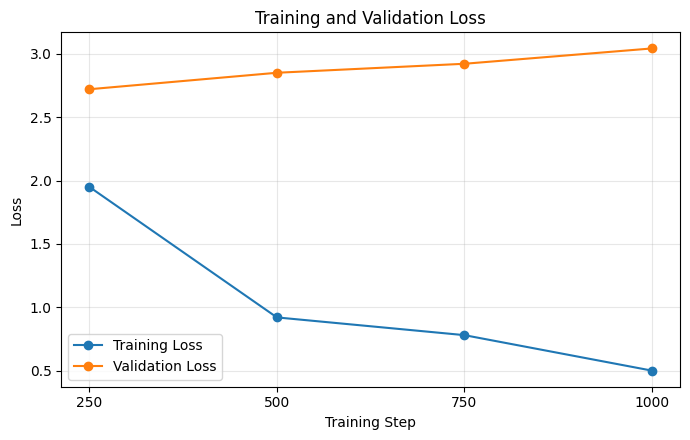

In [ ]:
plt.figure(figsize=(7, 4.5))

plt.plot(df["checkpoint"], df["train_loss"], marker="o", label="Training Loss")
plt.plot(df["checkpoint"], df["val_loss"], marker="o", label="Validation Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(df["checkpoint"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{save_dir}/loss_curve.png", dpi=300)
plt.show()

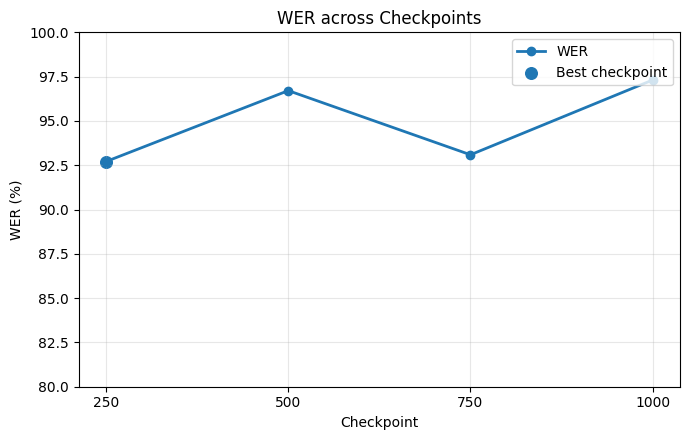

In [ ]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    df["checkpoint"],
    df["wer"],
    marker="o",
    linewidth=2,
    label="WER"
)

plt.xlabel("Checkpoint")
plt.ylabel("WER (%)")
plt.title("WER across Checkpoints")

plt.xticks(df["checkpoint"])
plt.ylim(80, 100)

plt.grid(True, alpha=0.3)

best_idx = df["wer"].idxmin()

plt.scatter(
    df.loc[best_idx, "checkpoint"],
    df.loc[best_idx, "wer"],
    s=70,
    label="Best checkpoint"
)

plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"{save_dir}/wer_curve.png", dpi=300)
plt.show()

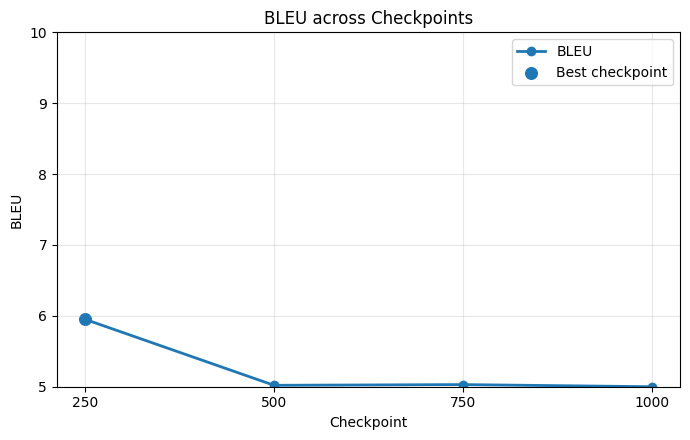

In [ ]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    df["checkpoint"],
    df["bleu"],
    marker="o",
    linewidth=2,
    label="BLEU"
)

plt.xlabel("Checkpoint")
plt.ylabel("BLEU")
plt.title("BLEU across Checkpoints")
plt.xticks(df["checkpoint"])
plt.ylim(5, 10)
plt.grid(True, alpha=0.3)

best_idx = df["bleu"].idxmax()

plt.scatter(
    df.loc[best_idx, "checkpoint"],
    df.loc[best_idx, "bleu"],
    s=70,
    label="Best checkpoint"
)

plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"{save_dir}/bleu_curve.png", dpi=300)
plt.show()

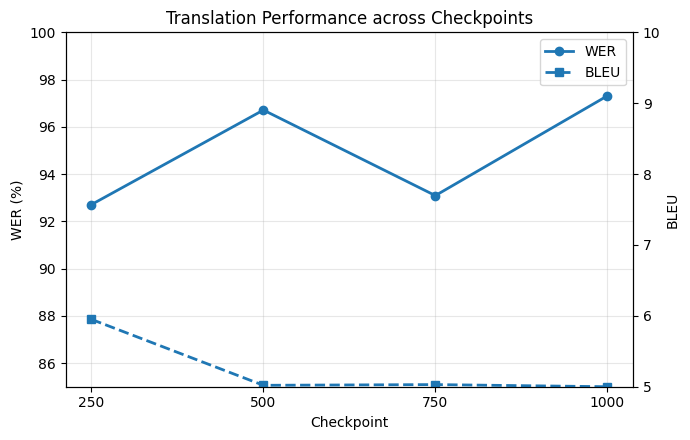

In [ ]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))

# WER
line1 = ax1.plot(
    df["checkpoint"],
    df["wer"],
    marker="o",
    linewidth=2,
    label="WER"
)

ax1.set_xlabel("Checkpoint")
ax1.set_ylabel("WER (%)")
ax1.set_xticks(df["checkpoint"])
ax1.set_ylim(85, 100)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

line2 = ax2.plot(
    df["checkpoint"],
    df["bleu"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="BLEU"
)

ax2.set_ylabel("BLEU")
ax2.set_ylim(5, 10)

lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="upper right")

plt.title("Translation Performance across Checkpoints")

fig.tight_layout()
plt.savefig(f"{save_dir}/wer_bleu_curve.png", dpi=300)
plt.show()

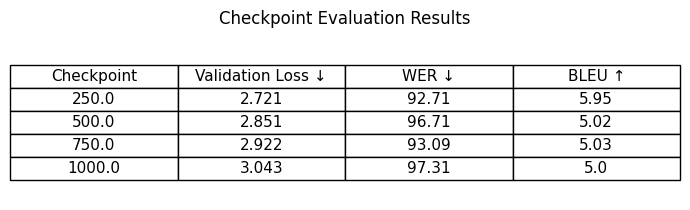

In [ ]:
table_df = df[["checkpoint", "val_loss", "wer", "bleu"]].copy()
table_df.columns = ["Checkpoint", "Validation Loss ↓", "WER ↓", "BLEU ↑"]

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.axis("off")

table = ax.table(
    cellText=table_df.round(3).values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

plt.title("Checkpoint Evaluation Results", pad=15)

plt.tight_layout()
plt.savefig(f"{save_dir}/results_table.png", dpi=300)
plt.show()

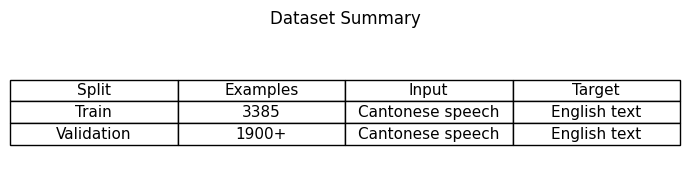

In [ ]:
dataset_df = pd.DataFrame({
    "Split": ["Train", "Validation"],
    "Examples": [3385, "1900+"],
    "Input": ["Cantonese speech", "Cantonese speech"],
    "Target": ["English text", "English text"]
})

fig, ax = plt.subplots(figsize=(7, 2))
ax.axis("off")

table = ax.table(
    cellText=dataset_df.values,
    colLabels=dataset_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

plt.title("Dataset Summary", pad=15)

plt.tight_layout()
plt.savefig(f"{save_dir}/dataset_table.png", dpi=300)
plt.show()